Post processing for 1 simulation result

In [23]:
"""Summarise EnergyPlus thermal-load energy in MWh annually or kWh for 3 days."""

from calendar import month_abbr, month_name
from pathlib import Path

import pandas as pd


JOULES_PER_UNIT = {
    "kWh": 3_600_000,
    "MWh": 3_600_000_000,
}

THERMAL_LOADS = {
    "Total_Cooling": "Zone Ideal Loads Supply Air Total Cooling Energy",
    "Sensible_Cooling": "Zone Ideal Loads Supply Air Sensible Cooling Energy",
    "Latent_Cooling": "Zone Ideal Loads Supply Air Latent Cooling Energy",
}


def find_columns(dataframe, variable_name):
    """Return all zone columns for one EnergyPlus output variable."""
    columns = [
        column
        for column in dataframe.columns
        if variable_name.lower() in str(column).lower()
    ]

    if not columns:
        raise ValueError(
            f"Could not find '{variable_name}' in the EnergyPlus CSV."
        )

    return columns


def extract_month(date_time_series):
    """Extract month numbers from hourly or monthly EnergyPlus output."""
    values = date_time_series.astype(str).str.strip()

    numeric_month = values.str.extract(
        r"^(\d{1,2})/\d{1,2}",
        expand=False,
    )

    month_lookup = {
        name.lower(): number
        for number, name in enumerate(month_name)
        if name
    }
    month_lookup.update({
        name.lower(): number
        for number, name in enumerate(month_abbr)
        if name
    })

    named_month = values.str.lower().map(month_lookup)

    month = pd.to_numeric(numeric_month, errors="coerce")
    month = month.fillna(named_month)

    if month.isna().any():
        bad_values = values[month.isna()].head().tolist()
        raise ValueError(
            "Could not determine the month from these Date/Time values: "
            f"{bad_values}"
        )

    return month.astype(int)


def determine_energy_unit(csv_path):
    """Use MWh for annual cases and kWh for three-day cases."""
    path_text = str(csv_path).lower()

    if "3days" in path_text or "3day" in path_text:
        return "kWh"

    if "annual" in path_text:
        return "MWh"

    raise ValueError(
        "Could not determine whether this is an annual or three-day case "
        "from the path."
    )


def process_energyplus_csv(csv_path):
    """Read one EnergyPlus CSV and print monthly and total cooling energy."""
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    energy_unit = determine_energy_unit(csv_path)
    conversion_factor = JOULES_PER_UNIT[energy_unit]

    data = pd.read_csv(csv_path, skipinitialspace=True)
    data.columns = [
        str(column).strip()
        for column in data.columns
    ]

    datetime_columns = [
        column
        for column in data.columns
        if "date/time" in column.lower()
    ]

    if len(datetime_columns) != 1:
        raise ValueError(
            f"Expected one Date/Time column in {csv_path.name}; "
            f"found {datetime_columns}."
        )

    energy_data = pd.DataFrame({
        "Month": extract_month(data[datetime_columns[0]])
    })

    output_columns = []

    for load_name, variable_name in THERMAL_LOADS.items():
        zone_columns = find_columns(data, variable_name)
        output_column = f"{load_name}_{energy_unit}"
        output_columns.append(output_column)

        zone_energy_joules = data[zone_columns].apply(
            pd.to_numeric,
            errors="raise",
        )

        energy_data[output_column] = (
            zone_energy_joules.sum(axis=1) / conversion_factor
        )

    monthly = (
        energy_data
        .groupby("Month", as_index=False)[output_columns]
        .sum()
    )

    monthly.insert(
        1,
        "Month_Name",
        monthly["Month"].map(lambda number: month_abbr[number]),
    )

    total = pd.DataFrame([{
        column: monthly[column].sum()
        for column in output_columns
    }])

    monthly = monthly.round(3)
    total = total.round(3)

    print(f"\nFILE: {csv_path}")
    print(f"ENERGY UNIT: {energy_unit}")

    print(f"\nMONTHLY THERMAL LOADS ({energy_unit})")
    print(monthly.to_string(index=False))

    if energy_unit == "MWh":
        print(f"\nANNUAL THERMAL LOADS ({energy_unit})")
    else:
        print(f"\nTHREE-DAY THERMAL LOADS ({energy_unit})")

    print(total.to_string(index=False))

    return monthly, total


CSV_PATH = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\blk863_EM_ConcreteWall_ACnormal_3days\blk863_EM_ConcreteWall_ACnormal_3days.csv")

monthly, total = process_energyplus_csv(CSV_PATH)


FILE: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\blk863_EM_ConcreteWall_ACnormal_3days\blk863_EM_ConcreteWall_ACnormal_3days.csv
ENERGY UNIT: kWh

MONTHLY THERMAL LOADS (kWh)
 Month Month_Name  Total_Cooling_kWh  Sensible_Cooling_kWh  Latent_Cooling_kWh
     2        Feb           4546.651              3691.752             854.899

THREE-DAY THERMAL LOADS (kWh)
 Total_Cooling_kWh  Sensible_Cooling_kWh  Latent_Cooling_kWh
          4546.651              3691.752             854.899


Annual post processing
- Ensure idf in monthly frequency not hourly
- 4 plots


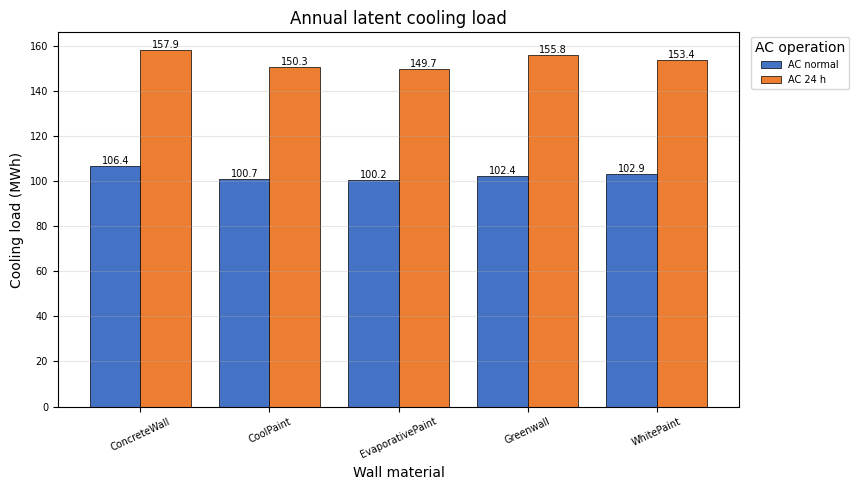

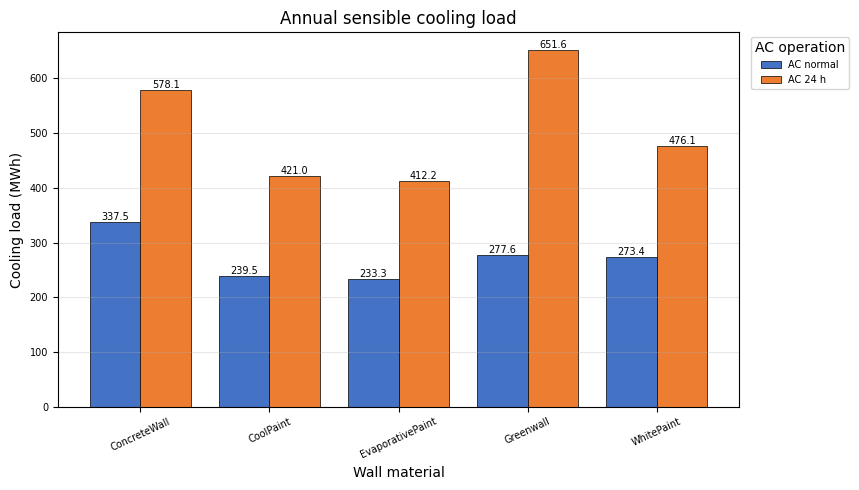

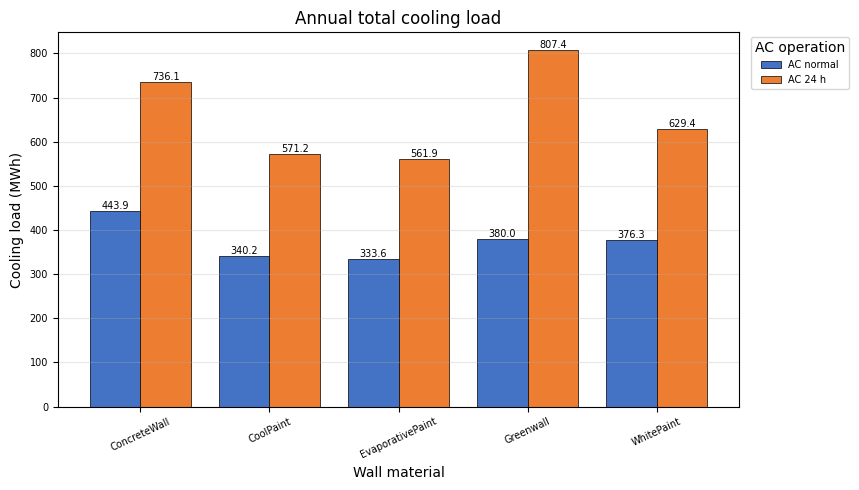

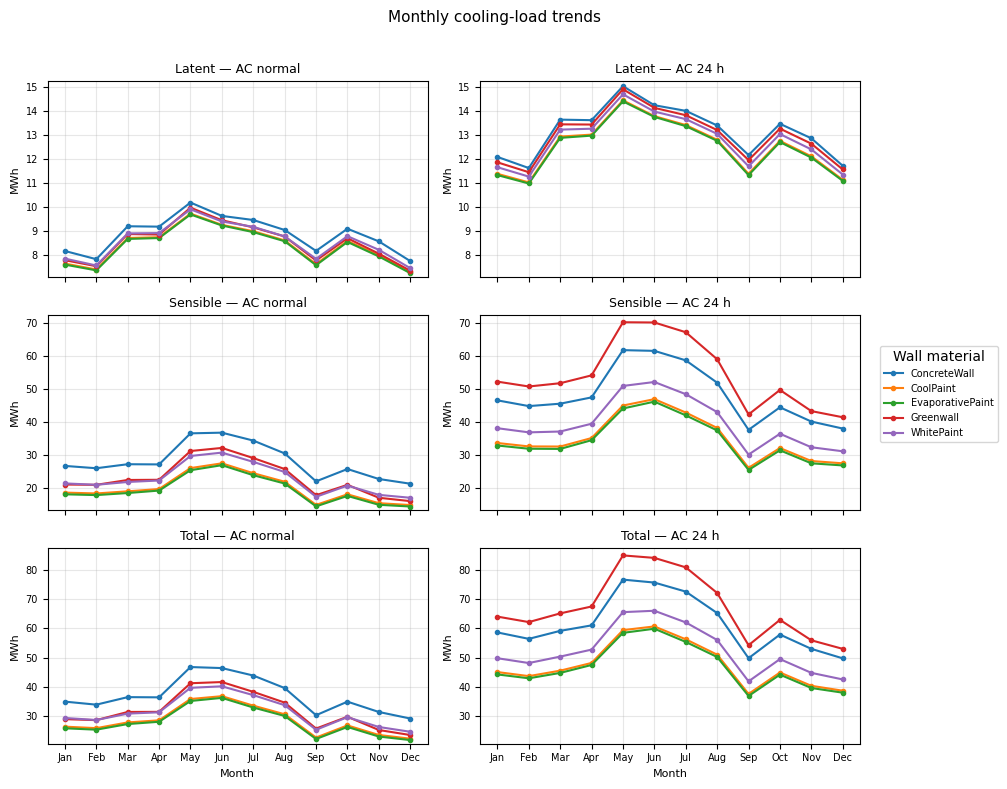

Saved to: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\postprocessing_charts


In [11]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# INPUT
# ============================================================

ROOT = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual"
)

OUT = ROOT / "postprocessing_charts"

J_TO_MWH = 3_600_000_000

LOADS = {
    "Latent": "Zone Ideal Loads Supply Air Latent Cooling Energy",
    "Sensible": "Zone Ideal Loads Supply Air Sensible Cooling Energy",
    "Total": "Zone Ideal Loads Supply Air Total Cooling Energy",
}

SCHEDULES = {
    "ACnormal": "AC normal",
    "AC24h": "AC 24 h",
}

MONTHS = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]


# ============================================================
# READ CASE
# ============================================================

def parse_folder(name):
    match = re.fullmatch(
        r"(blk863_EM|blk864)_(.+)_(ACnormal|AC24h)",
        name,
        re.I
    )

    if not match:
        return None

    block, material, schedule = match.groups()

    schedule = (
        "ACnormal"
        if schedule.lower() == "acnormal"
        else "AC24h"
    )

    return block, material, schedule


def get_csv(folder):
    return next(folder.glob("*.csv"))


def get_months(series):
    text = series.astype(str).str.strip()

    month_map = {
        month.lower(): i
        for i, month in enumerate(
            [
                "January", "February", "March", "April",
                "May", "June", "July", "August",
                "September", "October", "November", "December",
            ],
            1
        )
    }

    names = text.str.lower().map(month_map)

    numbers = pd.to_numeric(
        text.str.extract(r"^(\d{1,2})/", expand=False),
        errors="coerce"
    )

    return names.fillna(numbers).astype(int)


def process_case(csv_path, block, material, schedule):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    date_col = next(
        c for c in df.columns
        if "date/time" in c.lower().replace(" ", "")
        or "datetime" in c.lower().replace(" ", "")
    )

    months = get_months(df[date_col])

    annual = []
    monthly = []

    for load, variable in LOADS.items():

        cols = [
            c for c in df.columns
            if variable.lower() in c.lower()
        ]

        values = (
            df[cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .sum(axis=1)
            / J_TO_MWH
        )

        annual.append({
            "Block": block,
            "Material": material,
            "Schedule": schedule,
            "Load": load,
            "MWh": values.sum(),
        })

        monthly_values = values.groupby(months).sum()

        for month in range(1, 13):
            monthly.append({
                "Block": block,
                "Material": material,
                "Schedule": schedule,
                "Load": load,
                "Month": month,
                "MWh": monthly_values.get(month, 0),
            })

    return annual, monthly


# ============================================================
# ANNUAL PLOT
# ============================================================

def plot_annual(data, load, materials):
    pivot = (
        data[data["Load"] == load]
        .pivot(index="Material", columns="Schedule", values="MWh")
        .reindex(materials)
        .reindex(columns=["ACnormal", "AC24h"])
    )

    pivot.columns = [SCHEDULES[c] for c in pivot.columns]

    ax = pivot.plot(
        kind="bar",
        figsize=(10, 5),
        width=0.78,
        color=["#4472C4", "#ED7D31"],
        edgecolor="black",
        linewidth=0.5,
    )

    ax.set(
        title=f"Annual {load.lower()} cooling load",
        xlabel="Wall material",
        ylabel="Cooling load (MWh)",
    )

    ax.tick_params(axis="x", rotation=25, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="y", alpha=0.3)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="%.1f", fontsize=7)

    ax.legend(
        title="AC operation",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=7,
    )

    plt.tight_layout(rect=(0, 0, 0.87, 1))
    plt.savefig(
        OUT / f"annual_{load.lower()}_load.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()


# ============================================================
# MONTHLY PLOTS
# ============================================================

def plot_monthly(data, materials):
    fig, axes = plt.subplots(
        3, 2,
        figsize=(10, 8),
        sharex=True
    )

    for row, load in enumerate(LOADS):

        for col, schedule in enumerate(["ACnormal", "AC24h"]):
            ax = axes[row, col]

            subset = data[
                (data["Load"] == load)
                & (data["Schedule"] == schedule)
            ]

            for material in materials:
                d = subset[
                    subset["Material"] == material
                ].sort_values("Month")

                ax.plot(
                    d["Month"],
                    d["MWh"],
                    marker="o",
                    markersize=3,
                    linewidth=1.5,
                    label=material,
                )

            ax.set_title(
                f"{load} — {SCHEDULES[schedule]}",
                fontsize=9
            )

            ax.set_ylabel("MWh", fontsize=8)
            ax.set_xticks(range(1, 13), MONTHS)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.3)

        # Same y-scale for normal vs 24h
        ymin = min(
            axes[row, 0].get_ylim()[0],
            axes[row, 1].get_ylim()[0]
        )

        ymax = max(
            axes[row, 0].get_ylim()[1],
            axes[row, 1].get_ylim()[1]
        )

        axes[row, 0].set_ylim(ymin, ymax)
        axes[row, 1].set_ylim(ymin, ymax)

    for ax in axes[-1]:
        ax.set_xlabel("Month", fontsize=8)

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Wall material",
        bbox_to_anchor=(0.88, 0.5),
        loc="center left",
        fontsize=7,
    )

    fig.suptitle("Monthly cooling-load trends", fontsize=11)
    fig.tight_layout(rect=(0, 0, 0.88, 0.97))

    fig.savefig(
        OUT / "monthly_load_trends.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ============================================================
# MAIN
# ============================================================

annual = []
monthly = []

for folder in ROOT.iterdir():

    if not folder.is_dir():
        continue

    info = parse_folder(folder.name)

    if not info:
        continue

    block, material, schedule = info

    a, m = process_case(
        get_csv(folder),
        block,
        material,
        schedule
    )

    annual += a
    monthly += m


annual = pd.DataFrame(annual)
monthly = pd.DataFrame(monthly)

materials = annual["Material"].drop_duplicates().tolist()

OUT.mkdir(exist_ok=True)

annual.to_csv(
    OUT / "annual_load_summary_MWh.csv",
    index=False
)

monthly.to_csv(
    OUT / "monthly_load_summary_MWh.csv",
    index=False
)

for load in LOADS:
    plot_annual(annual, load, materials)

plot_monthly(monthly, materials)

print(f"Saved to: {OUT}")

3 Day post processing for BLK 864
- ensure outputs in hourly format
- 1 bar graph on total load comparison for diff material at normal and 24hr
- boxplot on mean living room temperature for normal AC (ignore for 24hr AC) to see temperature range
- line graph to see living room temp across the hours
- line graph to see 24hr AC cooling load acrross the hours

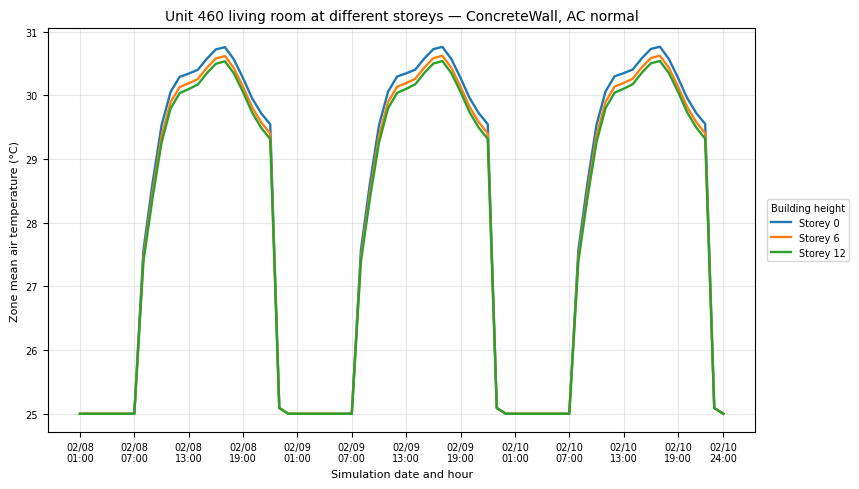

C:\Users\Heng_\AppData\Local\Temp\ipykernel_13212\3331450199.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,


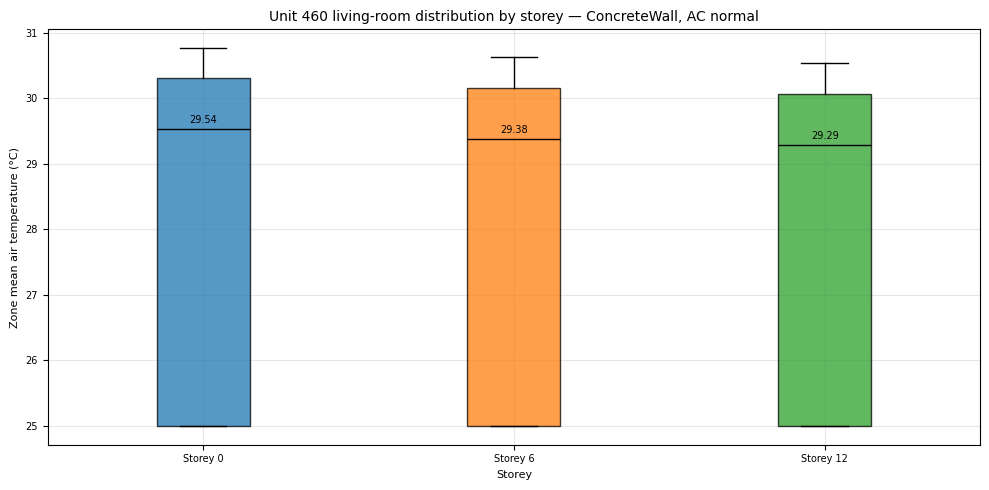

C:\Users\Heng_\AppData\Local\Temp\ipykernel_13212\3331450199.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,


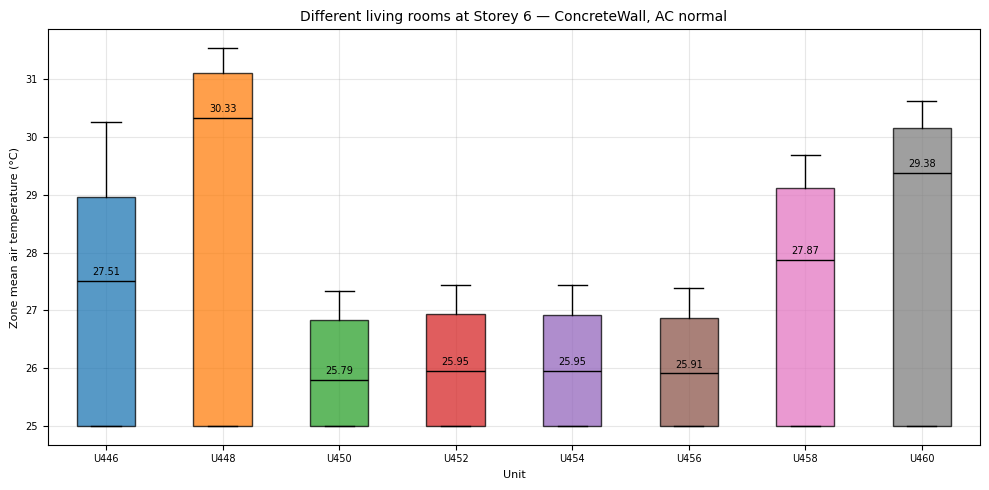

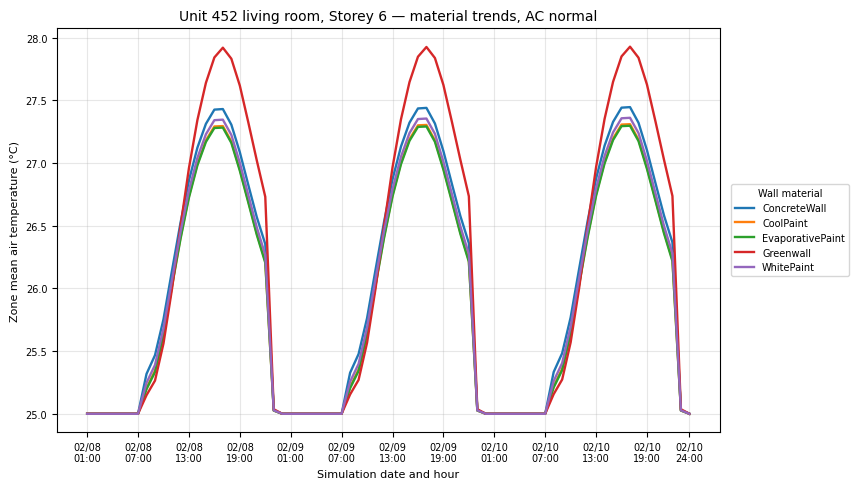

C:\Users\Heng_\AppData\Local\Temp\ipykernel_13212\3331450199.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,


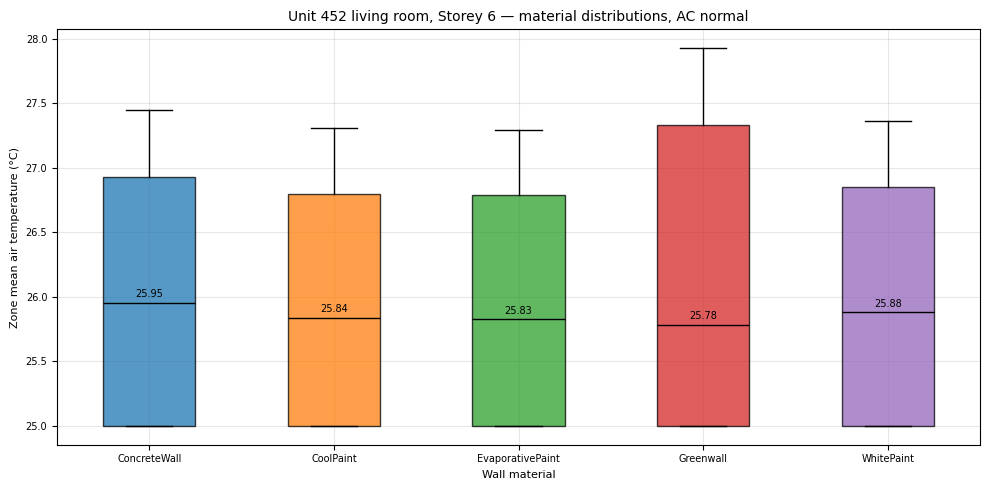

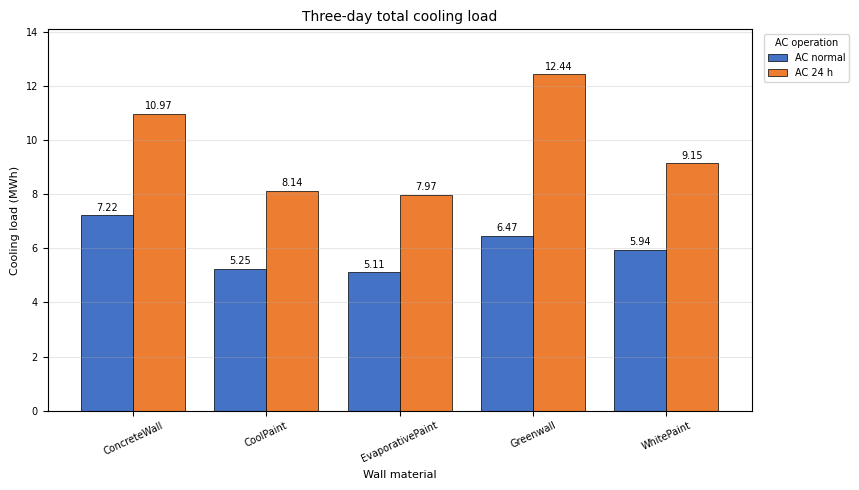

Saved 6 plots to: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\3 days\postprocessing_charts


In [17]:
"""
Outputs
-------
1. Unit 452 living-room trend across Storeys 0, 6, and 11.
2. Unit 452 living-room boxplot across Storeys 0, 6, and 11.
3. Living-room boxplot across all units at Storey 6.
4. Unit 452, Storey 6 living-room material trend.
5. Unit 452, Storey 6 living-room material boxplot.
6. Three-day total cooling-load comparison for both AC schedules.
"""

"""Three-day EnergyPlus temperature and cooling-load comparisons."""

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ========================== USER INPUTS ==========================
ROOT = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\3 days")

# Plots 1–2: one living room at several storeys
SAME_ROOM_UNIT = 460 # choose 1: 446, 448, 450, 452, 454, 456, 458, 460
SAME_ROOM_STOREYS = (0, 6, 12) # don't change this because my idf only has lvl 0, 6 and 11

# Plot 3: all living rooms at one storey
SAME_LEVEL_STOREY = 6 # choose 1: 0, 6 or 11

# Plots 4–5: one living room/storey across materials
WALL_MATERIAL_UNIT = 452 # choose 1: 446, 448, 450, 452, 454, 456, 458, 460 
WALL_MATERIAL_STOREY = 6 # choose 1: 0, 6 or 12
# Baseline for Plots 1–3
BASELINE_MATERIAL = "ConcreteWall"
TEMPERATURE_SCHEDULE = "ACnormal"
# ================================================================

OUT = ROOT / "postprocessing_charts"
J_PER_MWH = 3_600_000_000
TEMP_VAR = "Zone Mean Air Temperature"
LOAD_VAR = "Zone Ideal Loads Supply Air Total Cooling Energy"

SCHEDULE_NAMES = {"ACnormal": "AC normal", "AC24h": "AC 24 h"}
TITLE_FS, AXIS_FS, TICK_FS, LEGEND_FS, LABEL_FS = 10, 8, 7, 7, 7

def case_info(name):
    match = re.fullmatch(r"blk864_(.+)_(ACnormal|AC24h)_3days",name,re.I)
    if not match:
        return None
    material, schedule = match.groups()
    schedule = ("ACnormal" if schedule.lower() == "acnormal" else "AC24h")
    return material, schedule


def only_csv(folder):
    files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".csv"]
    if len(files) != 1:
        raise ValueError(f"Expected one CSV in {folder}; found {len(files)}")
    return files[0]


def find_columns(df, text):
    columns = [c for c in df.columns if text.lower() in str(c).lower()]
    if not columns:
        raise ValueError(f"CSV output not found: {text}")
    return columns


def room_name(column):
    match = re.search(r"UNIT\s+(\d+)_LIVINGROOM\s+STOREY\s+(\d+)", str(column), re.I)
    if not match:
        raise ValueError(f"Cannot read living-room name: {column}")
    return f"U{match.group(1)} S{match.group(2)}"


def read_case(csv_path, material, schedule):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    date_col = next((c for c in df.columns if "date/time" in re.sub(r"\s+", "", c).lower()), None)
    if date_col is None:
        raise ValueError(f"Date/Time column not found in {csv_path}")

    load = df[find_columns(df, LOAD_VAR)].apply(pd.to_numeric, errors="coerce").fillna(0)
    load_row = {"Material": material, "Schedule": schedule, "MWh": load.to_numpy().sum() / J_PER_MWH}

    rows = []
    for column in [c for c in find_columns(df, TEMP_VAR) if "livingroom" in c.lower()]:
        for hour, value in pd.to_numeric(df[column], errors="coerce").items():
            if pd.notna(value):
                rows.append({
                    "Material": material,
                    "Schedule": schedule,
                    "Room": room_name(column),
                    "Hour": hour,
                    "DateTime": str(df.at[hour, date_col]).strip(),
                    "Temperature": float(value),
                })
    return load_row, rows


def load_results():
    loads, temperatures, seen = [], [], set()
    for folder in sorted(ROOT.iterdir()):
        info = case_info(folder.name) if folder.is_dir() else None
        if not info:
            continue
        if info in seen:
            raise ValueError(f"Duplicate case: {folder.name}")
        load, temp = read_case(only_csv(folder), *info)
        loads.append(load)
        temperatures.extend(temp)
        seen.add(info)
    if not loads:
        raise ValueError(f"No matching case folders found in {ROOT}")
    return pd.DataFrame(loads), pd.DataFrame(temperatures)


def time_label(value):
    match = re.fullmatch(r"\s*(\d{1,2}/\d{1,2})\s+(\d{1,2}):\d{2}:\d{2}\s*", str(value))
    return f"{match.group(1)}\n{int(match.group(2)):02d}:00" if match else str(value).strip()


def add_time_ticks(axis, data):
    ref = data.sort_values("Hour").drop_duplicates("Hour")[["Hour", "DateTime"]].reset_index(drop=True)
    indices = list(range(0, len(ref), 6))
    if len(ref) - 1 not in indices:
        indices.append(len(ref) - 1)
    ticks = ref.iloc[indices]
    axis.set_xticks(ticks["Hour"], [time_label(x) for x in ticks["DateTime"]])


def finish(fig, axis, title, xlabel, filename, legend_title=None):
    axis.set_title(title, fontsize=TITLE_FS)
    axis.set_xlabel(xlabel, fontsize=AXIS_FS)
    axis.set_ylabel("Zone mean air temperature (°C)", fontsize=AXIS_FS)
    axis.tick_params(axis="both", labelsize=TICK_FS)
    axis.grid(alpha=0.3)
    if legend_title:
        axis.legend(title=legend_title, loc="center left", bbox_to_anchor=(1.01, 0.5),
                    fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    fig.tight_layout(rect=(0, 0, 0.87 if legend_title else 1, 1))
    fig.savefig(OUT / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def line_plot(data, groups, title, legend_title, filename):
    fig, axis = plt.subplots(figsize=(10, 5))
    for label, query in groups:
        values = data.query(query).sort_values("Hour")
        if values.empty:
            raise ValueError(f"No data for {label}")
        axis.plot(values["Hour"], values["Temperature"], linewidth=1.7, label=label)
    add_time_ticks(axis, data)
    finish(fig, axis, title, "Simulation date and hour", filename, legend_title)


def box_plot(data, groups, title, xlabel, filename):
    labels, values = [], []
    for label, query in groups:
        series = data.query(query)["Temperature"].dropna().to_numpy()
        if not len(series):
            raise ValueError(f"No data for {label}")
        labels.append(label)
        values.append(series)

    fig, axis = plt.subplots(figsize=(10, 5))
    result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,
                          medianprops={"color": "black"})
    colours = plt.get_cmap("tab10").colors
    for i, box in enumerate(result["boxes"]):
        box.set_facecolor(colours[i % len(colours)])
        box.set_alpha(0.75)
    for i, median in enumerate(result["medians"], 1):
        value = median.get_ydata()[0]
        axis.annotate(f"{value:.2f}", (i, value), xytext=(0, 4), textcoords="offset points",
                      ha="center", fontsize=LABEL_FS)
    finish(fig, axis, title, xlabel, filename)


def plot_total_load(loads, materials):
    pivot = loads.pivot(index="Material", columns="Schedule", values="MWh")
    pivot = pivot.reindex(index=materials, columns=["ACnormal", "AC24h"])
    pivot.columns = [SCHEDULE_NAMES[c] for c in pivot.columns]
    axis = pivot.plot(kind="bar", figsize=(10, 5), width=0.78,
                      color=["#4472C4", "#ED7D31"], edgecolor="black", linewidth=0.5)
    axis.set_title("Three-day total cooling load", fontsize=TITLE_FS)
    axis.set_xlabel("Wall material", fontsize=AXIS_FS)
    axis.set_ylabel("Cooling load (MWh)", fontsize=AXIS_FS)
    axis.tick_params(axis="x", rotation=25, labelsize=TICK_FS)
    axis.tick_params(axis="y", labelsize=TICK_FS)
    axis.grid(axis="y", alpha=0.3)
    for container in axis.containers:
        axis.bar_label(container, fmt="%.2f", padding=2, fontsize=LABEL_FS)
    axis.set_ylim(top=axis.get_ylim()[1] * 1.08)
    axis.legend(title="AC operation", loc="upper left", bbox_to_anchor=(1.01, 1),
                fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    plt.tight_layout(rect=(0, 0, 0.87, 1))
    plt.savefig(OUT / "06_three_day_total_cooling_load.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def validate(temps, materials):
    if BASELINE_MATERIAL not in materials:
        raise ValueError(f"Material not found: {BASELINE_MATERIAL}")
    rooms = set(temps["Room"])
    requested = {f"U{SAME_ROOM_UNIT} S{s}" for s in SAME_ROOM_STOREYS}
    requested.add(f"U{WALL_MATERIAL_UNIT} S{WALL_MATERIAL_STOREY}")
    if requested - rooms:
        raise ValueError("Rooms not found: " + ", ".join(sorted(requested - rooms)))
    if not any(r.endswith(f" S{SAME_LEVEL_STOREY}") for r in rooms):
        raise ValueError(f"Storey not found: {SAME_LEVEL_STOREY}")


def main():
    loads, temps = load_results()
    materials = sorted(loads["Material"].unique(), key=str.lower)
    validate(temps, materials)
    OUT.mkdir(parents=True, exist_ok=True)

    baseline = temps.query("Material == @BASELINE_MATERIAL and Schedule == @TEMPERATURE_SCHEDULE")
    levels = [(f"Storey {s}", f"Room == 'U{SAME_ROOM_UNIT} S{s}'") for s in SAME_ROOM_STOREYS]
    same_level_rooms = sorted(
        [r for r in baseline["Room"].unique() if r.endswith(f" S{SAME_LEVEL_STOREY}")],
        key=lambda r: int(r.split()[0][1:]),
    )
    rooms = [(r.split()[0], f"Room == '{r}'") for r in same_level_rooms]

    material_room = f"U{WALL_MATERIAL_UNIT} S{WALL_MATERIAL_STOREY}"
    material_data = temps.query("Room == @material_room and Schedule == @TEMPERATURE_SCHEDULE")
    material_groups = [(m, f"Material == '{m}'") for m in materials]

    line_plot(baseline, levels,
              f"Unit {SAME_ROOM_UNIT} living room at different storeys — {BASELINE_MATERIAL}, AC normal",
              "Building height", f"01_unit_{SAME_ROOM_UNIT}_different_storeys_line.png")
    box_plot(baseline, levels,
             f"Unit {SAME_ROOM_UNIT} living-room distribution by storey — {BASELINE_MATERIAL}, AC normal",
             "Storey", f"02_unit_{SAME_ROOM_UNIT}_different_storeys_boxplot.png")
    box_plot(baseline, rooms,
             f"Different living rooms at Storey {SAME_LEVEL_STOREY} — {BASELINE_MATERIAL}, AC normal",
             "Unit", f"03_storey_{SAME_LEVEL_STOREY}_different_rooms_boxplot.png")
    line_plot(material_data, material_groups,
              f"Unit {WALL_MATERIAL_UNIT} living room, Storey {WALL_MATERIAL_STOREY} — material trends, AC normal",
              "Wall material", f"04_unit_{WALL_MATERIAL_UNIT}_storey_{WALL_MATERIAL_STOREY}_materials_line.png")
    box_plot(material_data, material_groups,
             f"Unit {WALL_MATERIAL_UNIT} living room, Storey {WALL_MATERIAL_STOREY} — material distributions, AC normal",
             "Wall material", f"05_unit_{WALL_MATERIAL_UNIT}_storey_{WALL_MATERIAL_STOREY}_materials_boxplot.png")
    plot_total_load(loads, materials)

    loads.to_csv(OUT / "three_day_total_load_MWh.csv", index=False)
    temps.to_csv(OUT / "three_day_living_room_temperatures.csv", index=False)
    print(f"Saved 6 plots to: {OUT}")


if __name__ == "__main__":
    main()

3 Day post processing for BLK 863_EM
- ensure outputs in hourly format
- 1 bar graph on total load comparison for diff material at normal and 24hr
- boxplot on mean living room temperature for normal AC (ignore for 24hr AC) to see temperature range
- line graph to see living room temp across the hours
- line graph to see 24hr AC cooling load acrross the hours

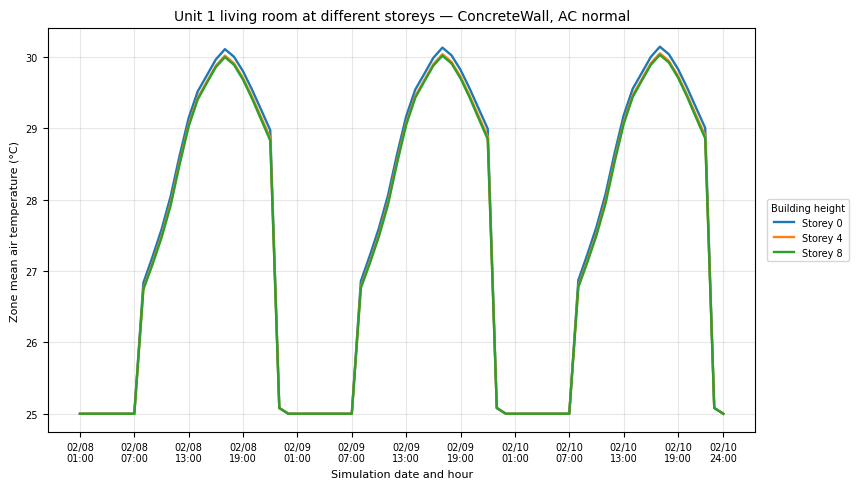

C:\Users\Heng_\AppData\Local\Temp\ipykernel_13212\2196494920.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,


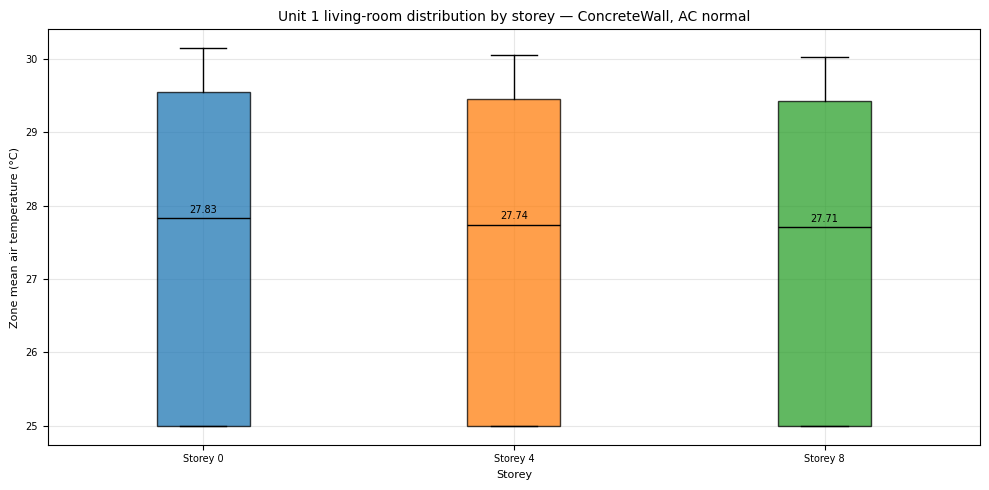

C:\Users\Heng_\AppData\Local\Temp\ipykernel_13212\2196494920.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,


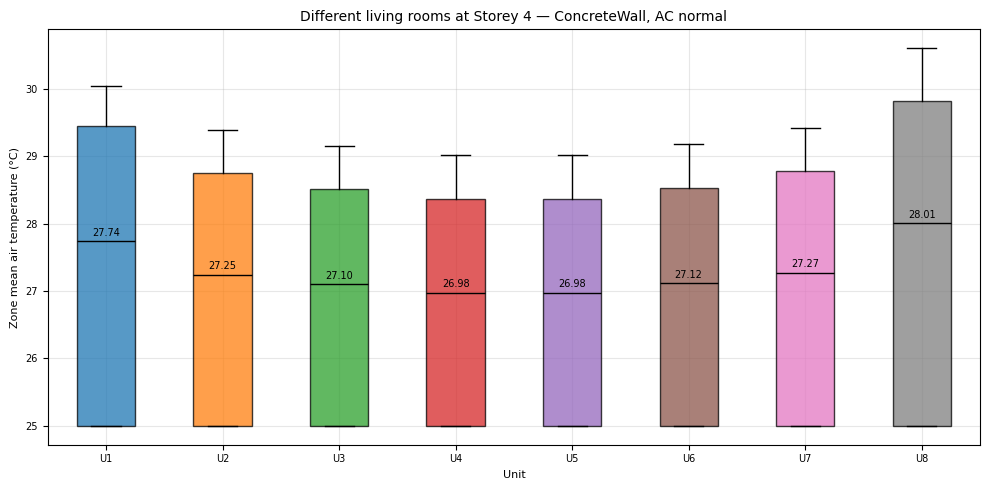

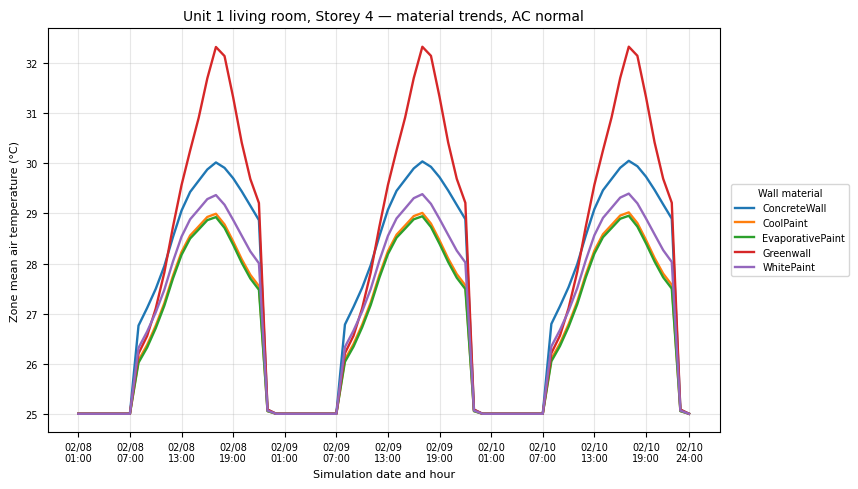

C:\Users\Heng_\AppData\Local\Temp\ipykernel_13212\2196494920.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,


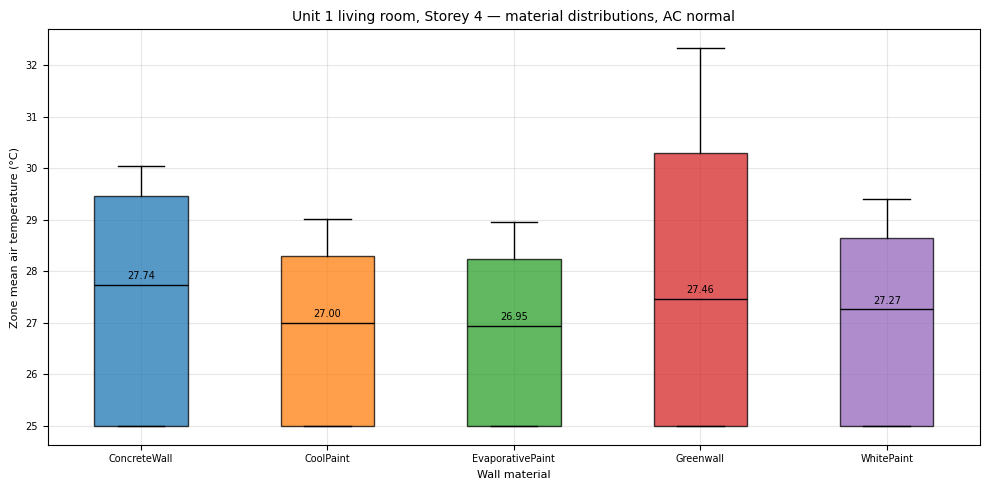

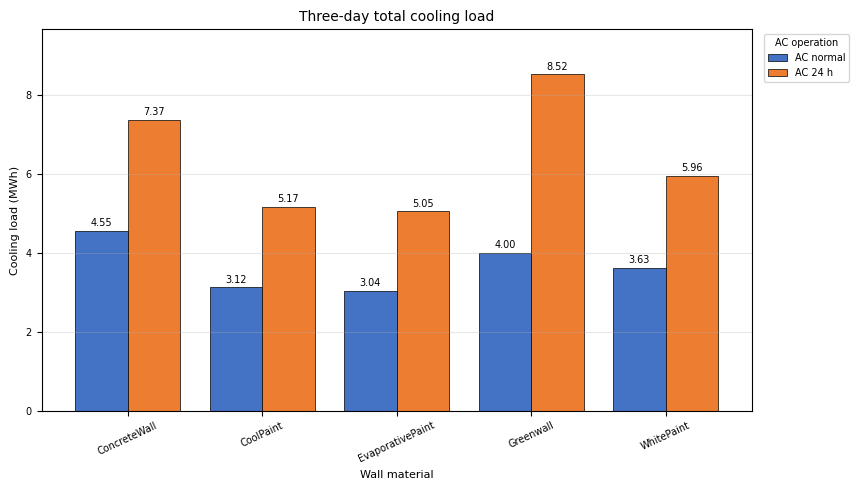

Saved 6 plots to: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\postprocessing_charts


In [21]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ========================== USER INPUTS ==========================
ROOT = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days")

# Plots 1–2: one living room at several storeys
SAME_ROOM_UNIT = 1 # choose 1 to 8
SAME_ROOM_STOREYS = (0, 4, 8) # don't change this because my idf only has lvl 0, 4 and 8

# Plot 3: all living rooms at one storey
SAME_LEVEL_STOREY = 4 # choose 1: 0, 4 or 8

# Plots 4–5: one living room/storey across materials
WALL_MATERIAL_UNIT = 1 # choose 1 to 8
WALL_MATERIAL_STOREY = 4 # choose 1: 0, 4 or 8
# Baseline for Plots 1–3
BASELINE_MATERIAL = "ConcreteWall"
TEMPERATURE_SCHEDULE = "ACnormal"
# ================================================================

OUT = ROOT / "postprocessing_charts"
J_PER_MWH = 3_600_000_000
TEMP_VAR = "Zone Mean Air Temperature"
LOAD_VAR = "Zone Ideal Loads Supply Air Total Cooling Energy"

SCHEDULE_NAMES = {"ACnormal": "AC normal", "AC24h": "AC 24 h"}
TITLE_FS, AXIS_FS, TICK_FS, LEGEND_FS, LABEL_FS = 10, 8, 7, 7, 7

def case_info(name):
    match = re.fullmatch(r"blk863_EM_(.+)_(ACnormal|AC24h)_3days",name,re.I)
    if not match:
        return None
    material, schedule = match.groups()
    schedule = ("ACnormal" if schedule.lower() == "acnormal" else "AC24h")
    return material, schedule


def only_csv(folder):
    files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".csv"]
    if len(files) != 1:
        raise ValueError(f"Expected one CSV in {folder}; found {len(files)}")
    return files[0]


def find_columns(df, text):
    columns = [c for c in df.columns if text.lower() in str(c).lower()]
    if not columns:
        raise ValueError(f"CSV output not found: {text}")
    return columns


def room_name(column):
    match = re.search(r"UNIT\s+(\d+)_LIVINGROOM\s+STOREY\s+(\d+)", str(column), re.I)
    if not match:
        raise ValueError(f"Cannot read living-room name: {column}")
    return f"U{match.group(1)} S{match.group(2)}"


def read_case(csv_path, material, schedule):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    date_col = next((c for c in df.columns if "date/time" in re.sub(r"\s+", "", c).lower()), None)
    if date_col is None:
        raise ValueError(f"Date/Time column not found in {csv_path}")

    load = df[find_columns(df, LOAD_VAR)].apply(pd.to_numeric, errors="coerce").fillna(0)
    load_row = {"Material": material, "Schedule": schedule, "MWh": load.to_numpy().sum() / J_PER_MWH}

    rows = []
    for column in [c for c in find_columns(df, TEMP_VAR) if "livingroom" in c.lower()]:
        for hour, value in pd.to_numeric(df[column], errors="coerce").items():
            if pd.notna(value):
                rows.append({
                    "Material": material,
                    "Schedule": schedule,
                    "Room": room_name(column),
                    "Hour": hour,
                    "DateTime": str(df.at[hour, date_col]).strip(),
                    "Temperature": float(value),
                })
    return load_row, rows


def load_results():
    loads, temperatures, seen = [], [], set()
    for folder in sorted(ROOT.iterdir()):
        info = case_info(folder.name) if folder.is_dir() else None
        if not info:
            continue
        if info in seen:
            raise ValueError(f"Duplicate case: {folder.name}")
        load, temp = read_case(only_csv(folder), *info)
        loads.append(load)
        temperatures.extend(temp)
        seen.add(info)
    if not loads:
        raise ValueError(f"No matching case folders found in {ROOT}")
    return pd.DataFrame(loads), pd.DataFrame(temperatures)


def time_label(value):
    match = re.fullmatch(r"\s*(\d{1,2}/\d{1,2})\s+(\d{1,2}):\d{2}:\d{2}\s*", str(value))
    return f"{match.group(1)}\n{int(match.group(2)):02d}:00" if match else str(value).strip()


def add_time_ticks(axis, data):
    ref = data.sort_values("Hour").drop_duplicates("Hour")[["Hour", "DateTime"]].reset_index(drop=True)
    indices = list(range(0, len(ref), 6))
    if len(ref) - 1 not in indices:
        indices.append(len(ref) - 1)
    ticks = ref.iloc[indices]
    axis.set_xticks(ticks["Hour"], [time_label(x) for x in ticks["DateTime"]])


def finish(fig, axis, title, xlabel, filename, legend_title=None):
    axis.set_title(title, fontsize=TITLE_FS)
    axis.set_xlabel(xlabel, fontsize=AXIS_FS)
    axis.set_ylabel("Zone mean air temperature (°C)", fontsize=AXIS_FS)
    axis.tick_params(axis="both", labelsize=TICK_FS)
    axis.grid(alpha=0.3)
    if legend_title:
        axis.legend(title=legend_title, loc="center left", bbox_to_anchor=(1.01, 0.5),
                    fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    fig.tight_layout(rect=(0, 0, 0.87 if legend_title else 1, 1))
    fig.savefig(OUT / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def line_plot(data, groups, title, legend_title, filename):
    fig, axis = plt.subplots(figsize=(10, 5))
    for label, query in groups:
        values = data.query(query).sort_values("Hour")
        if values.empty:
            raise ValueError(f"No data for {label}")
        axis.plot(values["Hour"], values["Temperature"], linewidth=1.7, label=label)
    add_time_ticks(axis, data)
    finish(fig, axis, title, "Simulation date and hour", filename, legend_title)


def box_plot(data, groups, title, xlabel, filename):
    labels, values = [], []
    for label, query in groups:
        series = data.query(query)["Temperature"].dropna().to_numpy()
        if not len(series):
            raise ValueError(f"No data for {label}")
        labels.append(label)
        values.append(series)

    fig, axis = plt.subplots(figsize=(10, 5))
    result = axis.boxplot(values, labels=labels, patch_artist=True, showfliers=False,
                          medianprops={"color": "black"})
    colours = plt.get_cmap("tab10").colors
    for i, box in enumerate(result["boxes"]):
        box.set_facecolor(colours[i % len(colours)])
        box.set_alpha(0.75)
    for i, median in enumerate(result["medians"], 1):
        value = median.get_ydata()[0]
        axis.annotate(f"{value:.2f}", (i, value), xytext=(0, 4), textcoords="offset points",
                      ha="center", fontsize=LABEL_FS)
    finish(fig, axis, title, xlabel, filename)


def plot_total_load(loads, materials):
    pivot = loads.pivot(index="Material", columns="Schedule", values="MWh")
    pivot = pivot.reindex(index=materials, columns=["ACnormal", "AC24h"])
    pivot.columns = [SCHEDULE_NAMES[c] for c in pivot.columns]
    axis = pivot.plot(kind="bar", figsize=(10, 5), width=0.78,
                      color=["#4472C4", "#ED7D31"], edgecolor="black", linewidth=0.5)
    axis.set_title("Three-day total cooling load", fontsize=TITLE_FS)
    axis.set_xlabel("Wall material", fontsize=AXIS_FS)
    axis.set_ylabel("Cooling load (MWh)", fontsize=AXIS_FS)
    axis.tick_params(axis="x", rotation=25, labelsize=TICK_FS)
    axis.tick_params(axis="y", labelsize=TICK_FS)
    axis.grid(axis="y", alpha=0.3)
    for container in axis.containers:
        axis.bar_label(container, fmt="%.2f", padding=2, fontsize=LABEL_FS)
    axis.set_ylim(top=axis.get_ylim()[1] * 1.08)
    axis.legend(title="AC operation", loc="upper left", bbox_to_anchor=(1.01, 1),
                fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
    plt.tight_layout(rect=(0, 0, 0.87, 1))
    plt.savefig(OUT / "06_three_day_total_cooling_load.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def validate(temps, materials):
    if BASELINE_MATERIAL not in materials:
        raise ValueError(f"Material not found: {BASELINE_MATERIAL}")
    rooms = set(temps["Room"])
    requested = {f"U{SAME_ROOM_UNIT} S{s}" for s in SAME_ROOM_STOREYS}
    requested.add(f"U{WALL_MATERIAL_UNIT} S{WALL_MATERIAL_STOREY}")
    if requested - rooms:
        raise ValueError("Rooms not found: " + ", ".join(sorted(requested - rooms)))
    if not any(r.endswith(f" S{SAME_LEVEL_STOREY}") for r in rooms):
        raise ValueError(f"Storey not found: {SAME_LEVEL_STOREY}")


def main():
    loads, temps = load_results()
    materials = sorted(loads["Material"].unique(), key=str.lower)
    validate(temps, materials)
    OUT.mkdir(parents=True, exist_ok=True)

    baseline = temps.query("Material == @BASELINE_MATERIAL and Schedule == @TEMPERATURE_SCHEDULE")
    levels = [(f"Storey {s}", f"Room == 'U{SAME_ROOM_UNIT} S{s}'") for s in SAME_ROOM_STOREYS]
    same_level_rooms = sorted(
        [r for r in baseline["Room"].unique() if r.endswith(f" S{SAME_LEVEL_STOREY}")],
        key=lambda r: int(r.split()[0][1:]),
    )
    rooms = [(r.split()[0], f"Room == '{r}'") for r in same_level_rooms]

    material_room = f"U{WALL_MATERIAL_UNIT} S{WALL_MATERIAL_STOREY}"
    material_data = temps.query("Room == @material_room and Schedule == @TEMPERATURE_SCHEDULE")
    material_groups = [(m, f"Material == '{m}'") for m in materials]

    line_plot(baseline, levels,
              f"Unit {SAME_ROOM_UNIT} living room at different storeys — {BASELINE_MATERIAL}, AC normal",
              "Building height", f"01_unit_{SAME_ROOM_UNIT}_different_storeys_line.png")
    box_plot(baseline, levels,
             f"Unit {SAME_ROOM_UNIT} living-room distribution by storey — {BASELINE_MATERIAL}, AC normal",
             "Storey", f"02_unit_{SAME_ROOM_UNIT}_different_storeys_boxplot.png")
    box_plot(baseline, rooms,
             f"Different living rooms at Storey {SAME_LEVEL_STOREY} — {BASELINE_MATERIAL}, AC normal",
             "Unit", f"03_storey_{SAME_LEVEL_STOREY}_different_rooms_boxplot.png")
    line_plot(material_data, material_groups,
              f"Unit {WALL_MATERIAL_UNIT} living room, Storey {WALL_MATERIAL_STOREY} — material trends, AC normal",
              "Wall material", f"04_unit_{WALL_MATERIAL_UNIT}_storey_{WALL_MATERIAL_STOREY}_materials_line.png")
    box_plot(material_data, material_groups,
             f"Unit {WALL_MATERIAL_UNIT} living room, Storey {WALL_MATERIAL_STOREY} — material distributions, AC normal",
             "Wall material", f"05_unit_{WALL_MATERIAL_UNIT}_storey_{WALL_MATERIAL_STOREY}_materials_boxplot.png")
    plot_total_load(loads, materials)

    loads.to_csv(OUT / "three_day_total_load_MWh.csv", index=False)
    temps.to_csv(OUT / "three_day_living_room_temperatures.csv", index=False)
    print(f"Saved 6 plots to: {OUT}")


if __name__ == "__main__":
    main()

Clean up folders to only keep idf and csv
- Input either /annual or /3 days filepath

In [2]:
# Clean up all rubbish in annual / 3days folders
# Keep all IDF and CSV files; delete everything else.

import shutil
from pathlib import Path


TARGET_FOLDER = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b\annual")

KEEP_EXTENSIONS = {".idf", ".csv"}


def remove_unwanted_item(item):
    """Delete one unwanted item and continue if Windows has locked it."""
    try:
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()

        print(f"  Deleted: {item.name}")
        return True

    except PermissionError:
        print(f"  SKIPPED LOCKED ITEM: {item}")
        return False

    except OSError as error:
        print(f"  COULD NOT DELETE: {item}")
        print(f"    Reason: {error}")
        return False


def clean_case_folder(case_folder):
    """Keep all IDF and CSV files and delete everything else."""
    undeleted_items = []

    for item in case_folder.iterdir():
        if item.is_file() and item.suffix.lower() in KEEP_EXTENSIONS:
            print(f"  Kept: {item.name}")
            continue

        if not remove_unwanted_item(item):
            undeleted_items.append(item)

    return undeleted_items


def clean_all_case_folders():
    """Clean every immediate case folder inside TARGET_FOLDER."""
    if not TARGET_FOLDER.is_dir():
        raise FileNotFoundError(f"Target folder not found: {TARGET_FOLDER}")

    case_folders = sorted(
        folder
        for folder in TARGET_FOLDER.iterdir()
        if folder.is_dir()
    )

    if not case_folders:
        raise ValueError(f"No case folders found inside: {TARGET_FOLDER}")

    undeleted_items = []

    for case_folder in case_folders:
        print(f"\nCleaning: {case_folder.name}")
        undeleted_items.extend(clean_case_folder(case_folder))

    print("\nCleanup completed.")

    if undeleted_items:
        print("\nThe following locked items could not be deleted:")

        for item in undeleted_items:
            print(f"  {item}")

        print(
            "\nClose EnergyPlus, EP-Launch and any other program using "
            "these folders, then rerun the code."
        )


clean_all_case_folders()


Cleaning: 863b_concrete_AC24h
  Deleted: blk_863b_concrete_AC24h.audit
  Deleted: blk_863b_concrete_AC24h.bnd
  Kept: blk_863b_concrete_AC24h.csv
  Deleted: blk_863b_concrete_AC24h.dxf
  Deleted: blk_863b_concrete_AC24h.eio
  Deleted: blk_863b_concrete_AC24h.epJSONout
  Deleted: blk_863b_concrete_AC24h.err
  Deleted: blk_863b_concrete_AC24h.eso
  Deleted: blk_863b_concrete_AC24h.expidf
  Kept: blk_863b_concrete_AC24h.idf
  Deleted: blk_863b_concrete_AC24h.mdd
  Deleted: blk_863b_concrete_AC24h.mtd
  Deleted: blk_863b_concrete_AC24h.rdd
  Deleted: blk_863b_concrete_AC24h.rvaudit
  Deleted: blk_863b_concrete_AC24h.shd
  Deleted: blk_863b_concrete_AC24h.svg
  SKIPPED LOCKED ITEM: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b\annual\863b_concrete_AC24h\EPTEMP-00000001

Cleaning: 863b_concrete_ACnormal
  Deleted: blk_863b_concrete_ACnormal.audit
  Deleted: blk_863b_concrete_ACnormal.bnd
  Kept: blk_863b_concrete_ACnormal.csv
  Dele

Export into folder:
- Enter either /863b or /864 or /863_EM folder (up to user), enter /3 days folder and /annual folder, then enter the case folders to copy the idf and csv file into a new folder called /results in the same directory as /3 days and /annual


In [1]:
from pathlib import Path
import shutil


# ================= USER INPUT =================

BASE = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf"
)

BLOCK = "863_EM"   # choose: "863b", "864", "863_EM"

# ==============================================


block_folder = BASE / f"blk{BLOCK}"
results = block_folder / "results"

for period in ["3 days", "annual"]:

    source = block_folder / period
    destination = results / period

    destination.mkdir(parents=True, exist_ok=True)

    for case_folder in source.iterdir():

        if not case_folder.is_dir():
            continue

        for file in case_folder.iterdir():

            if file.suffix.lower() in {".idf", ".csv"}:

                shutil.copy2(
                    file,
                    destination / file.name
                )

                print(
                    f"{period}: {file.name}"
                )

print(f"\nResults copied to:\n{results}")

3 days: blk863_EM_ConcreteWall_AC24h_3days.csv
3 days: blk863_EM_ConcreteWall_AC24h_3days.idf
3 days: blk863_EM_ConcreteWall_ACnormal_3days.csv
3 days: blk863_EM_ConcreteWall_ACnormal_3days.idf
3 days: blk863_EM_CoolPaint_AC24h_3days.csv
3 days: blk863_EM_CoolPaint_AC24h_3days.idf
3 days: blk863_EM_CoolPaint_ACnormal_3days.csv
3 days: blk863_EM_CoolPaint_ACnormal_3days.idf
3 days: blk863_EM_EvaporativePaint_AC24h_3days.csv
3 days: blk863_EM_EvaporativePaint_AC24h_3days.idf
3 days: blk863_EM_EvaporativePaint_ACnormal_3days.csv
3 days: blk863_EM_EvaporativePaint_ACnormal_3days.idf
3 days: blk863_EM_Greenwall_AC24h_3days.csv
3 days: blk863_EM_Greenwall_AC24h_3days.idf
3 days: blk863_EM_Greenwall_ACnormal_3days.csv
3 days: blk863_EM_Greenwall_ACnormal_3days.idf
3 days: blk863_EM_WhitePaint_AC24h_3days.csv
3 days: blk863_EM_WhitePaint_AC24h_3days.idf
3 days: blk863_EM_WhitePaint_ACnormal_3days.csv
3 days: blk863_EM_WhitePaint_ACnormal_3days.idf
3 days: three_day_living_room_temperatures.csv